In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def naive_matrix_multiply(A, B):
    """
    Multiplies two square matrices A and B using basic nested loops.
    """
    n = len(A)
    # Initialize an empty matrix of the same size with zeros
    result = [[0.0 for _ in range(n)] for _ in range(n)]
    
    # Iterate through rows of A
    for i in range(n):
        # Iterate through columns of B
        for j in range(n):
            # Iterate through rows of B
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]
                
    return result

In [3]:
# Configuration
num_pairs = 8
base_size = 3
sizes = [base_size * (2**i) for i in range(num_pairs)]

naive_runtimes = []
numpy_runtimes = []

print("Starting matrix multiplications...")

for idx, size in enumerate(sizes):
    # 1. Build the pairs of random matrices using NumPy
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    # Convert to standard Python lists for the pure naive implementation
    A_list = A_np.tolist()
    B_list = B_np.tolist()
    
    # 2. Time the Naive implementation
    start_time_naive = time.perf_counter()
    naive_matrix_multiply(A_list, B_list)
    end_time_naive = time.perf_counter()
    naive_time = end_time_naive - start_time_naive
    naive_runtimes.append(naive_time)
    
    # 3. Time the Optimized (NumPy) implementation
    start_time_np = time.perf_counter()
    np.matmul(A_np, B_np) # Can also be written as A_np @ B_np
    end_time_np = time.perf_counter()
    numpy_time = end_time_np - start_time_np
    numpy_runtimes.append(numpy_time)
    
    print(f"Pair {idx+1} ({size}x{size}) -> Naive: {naive_time:.6f}s | NumPy: {numpy_time:.6f}s")

print("Multiplications complete!")

Starting matrix multiplications...
Pair 1 (3x3) -> Naive: 0.000020s | NumPy: 0.000128s
Pair 2 (6x6) -> Naive: 0.000066s | NumPy: 0.000024s
Pair 3 (12x12) -> Naive: 0.000431s | NumPy: 0.000013s
Pair 4 (24x24) -> Naive: 0.002646s | NumPy: 0.000053s
Pair 5 (48x48) -> Naive: 0.019615s | NumPy: 0.000087s
Pair 6 (96x96) -> Naive: 0.146364s | NumPy: 0.000324s
Pair 7 (192x192) -> Naive: 1.153319s | NumPy: 0.000832s
Pair 8 (384x384) -> Naive: 9.646718s | NumPy: 0.003691s
Multiplications complete!


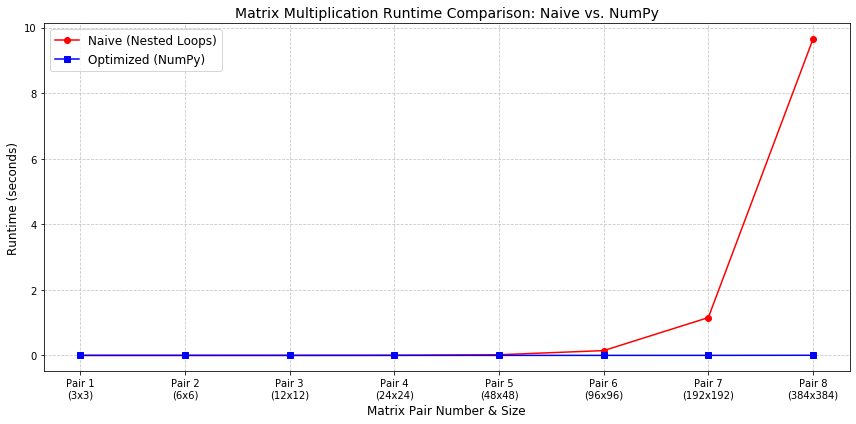

In [4]:
# X-axis labels
matrix_numbers = list(range(1, num_pairs + 1))
x_ticks_labels = [f"Pair {i}\n({s}x{s})" for i, s in zip(matrix_numbers, sizes)]

plt.figure(figsize=(12, 6))

# Plot both sets of runtimes
plt.plot(matrix_numbers, naive_runtimes, marker='o', color='red', label='Naive (Nested Loops)')
plt.plot(matrix_numbers, numpy_runtimes, marker='s', color='blue', label='Optimized (NumPy)')

# Formatting the chart
plt.title('Matrix Multiplication Runtime Comparison: Naive vs. NumPy', fontsize=14)
plt.xlabel('Matrix Pair Number & Size', fontsize=12)
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.xticks(matrix_numbers, x_ticks_labels)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()